# Analyse exploratoire ERA5 — Tunisie & Méditerranée (1980–2024)

**Question :** Comment les vagues de chaleur et le stress hydrique en Tunisie et en Méditerranée ont-ils évolué entre 1980 et 2024 ? Quelles sont les relations entre température, humidité et précipitations ?

**Données :** ERA5 réanalyse Copernicus, journalière, 3 variables (T2m, RH, précipitations).

**Migration R → Python :**
| Traitement R (S1) | Équivalent Python |
|---|---|
| `dplyr::filter(year >= 1980)` | `df[df.year >= 1980]` |
| `group_by + summarise(mean=...)` | `df.groupby(...).mean()` |
| `ggplot + geom_line` | `seaborn.lineplot` / `plotly.express.line` |
| `ggplot + geom_boxplot` | `seaborn.boxplot` |
| `lm(y ~ x)` | `scipy.stats.linregress` / `statsmodels.OLS` |

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path('..').resolve()
DATA = PROJECT_ROOT / 'data' / 'processed' / 'era5_daily.parquet'

df = pd.read_parquet(DATA)
df['date'] = pd.to_datetime(df['date'])
print(f'Lignes : {len(df):,}')
print(f'Période : {df.date.min().date()} → {df.date.max().date()}')
print(f'Zones : {df.zone.unique()}')
df.head()

Lignes : 32,874
Période : 1980-01-01 → 2024-12-31
Zones : ['mediterranee' 'tunisie']


,date,year,month,season,zone,t2m,d2m,rh,tp
0,1980-01-01 12:00:00,1980,1,DJF,mediterranee,11.686298,3.688222,61.625305,0.127247
1,1980-01-02 12:00:00,1980,1,DJF,mediterranee,11.226440,3.159787,61.316261,0.097736
2,1980-01-03 12:00:00,1980,1,DJF,mediterranee,10.444486,2.543439,61.509197,0.133025
3,1980-01-04 12:00:00,1980,1,DJF,mediterranee,9.700102,1.738042,60.578163,0.092826
4,1980-01-05 12:00:00,1980,1,DJF,mediterranee,9.289001,1.362613,60.960831,0.099035


## 1. Tendance long terme — Température moyenne annuelle

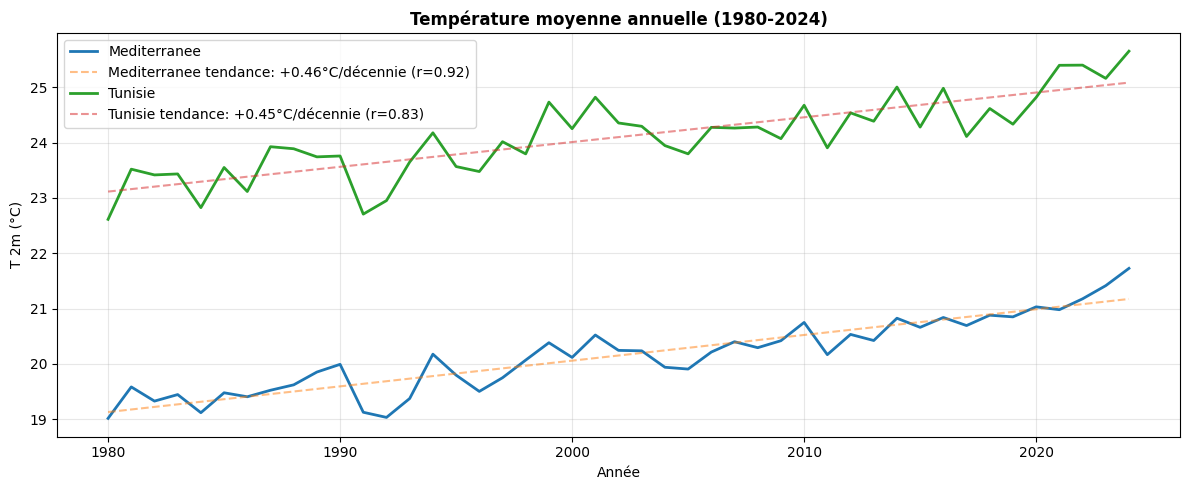

In [2]:
annual = df.groupby(['year', 'zone'])[['t2m', 'rh', 'tp']].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for zone, sub in annual.groupby('zone'):
    ax.plot(sub.year, sub.t2m, label=zone.title(), linewidth=2)
    # Tendance linéaire
    slope, intercept, r, p, _ = stats.linregress(sub.year, sub.t2m)
    ax.plot(sub.year, slope*sub.year+intercept, '--', alpha=0.5,
            label=f'{zone.title()} tendance: +{slope*10:.2f}°C/décennie (r={r:.2f})')
ax.set_title('Température moyenne annuelle (1980-2024)', fontweight='bold')
ax.set_xlabel('Année'); ax.set_ylabel('T 2m (°C)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Saisonnalité — Boxplots par saison (Tunisie)

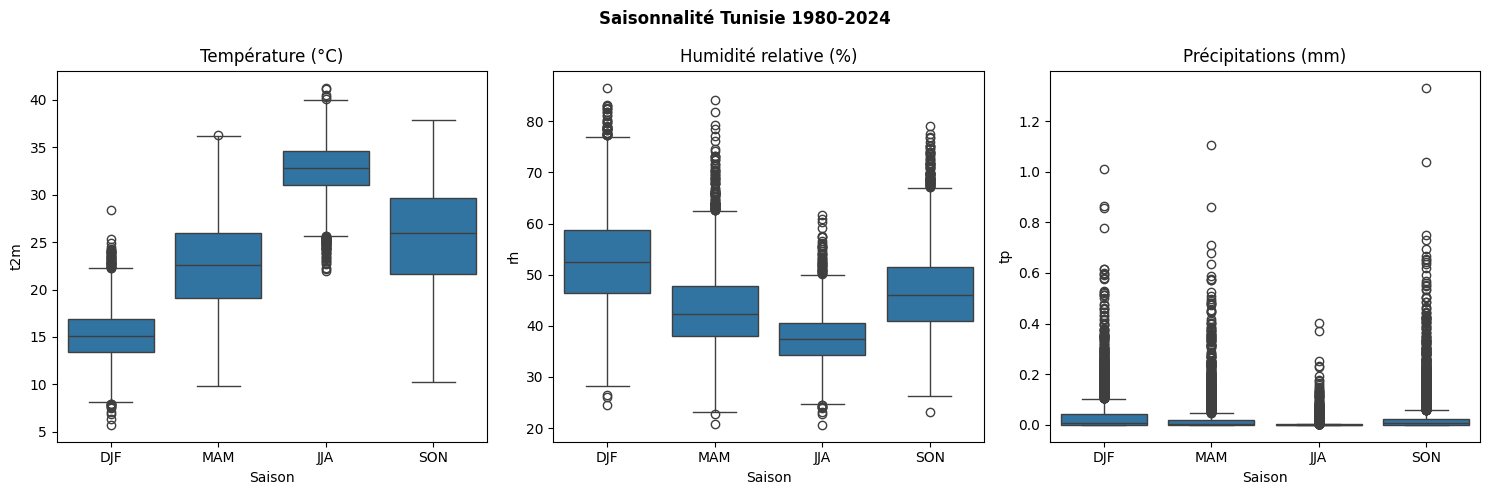

In [3]:
tun = df[df.zone == 'tunisie'].copy()
tun['decade'] = (tun.year // 10) * 10

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var, label in zip(axes, ['t2m', 'rh', 'tp'],
                          ['Température (°C)', 'Humidité relative (%)', 'Précipitations (mm)']):
    sns.boxplot(data=tun, x='season', y=var,
                order=['DJF','MAM','JJA','SON'], ax=ax)
    ax.set_title(label); ax.set_xlabel('Saison')
fig.suptitle('Saisonnalité Tunisie 1980-2024', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Vagues de chaleur — Évolution du nombre de jours > seuil

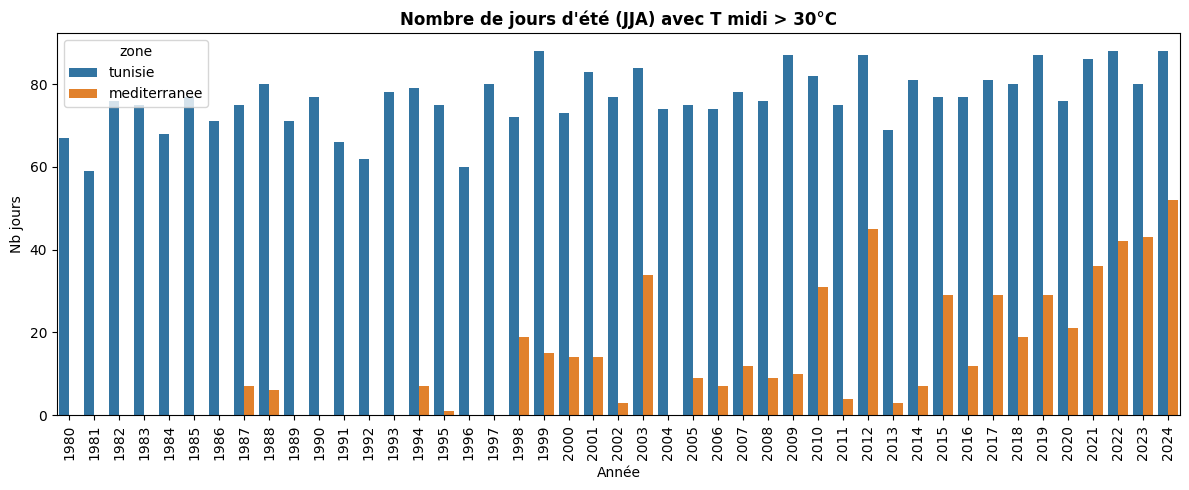

In [4]:
# Définition vague de chaleur : t2m midi > 30°C en été (JJA)
summer = df[(df.season == 'JJA')].copy()
heatwaves = (summer[summer.t2m > 30]
             .groupby(['year', 'zone'])
             .size()
             .reset_index(name='n_jours_chauds'))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=heatwaves, x='year', y='n_jours_chauds', hue='zone', ax=ax)
ax.set_title('Nombre de jours d\'été (JJA) avec T midi > 30°C', fontweight='bold')
ax.set_xlabel('Année'); ax.set_ylabel('Nb jours')
for label in ax.get_xticklabels(): label.set_rotation(90)
plt.tight_layout(); plt.show()

## 4. Corrélations entre variables

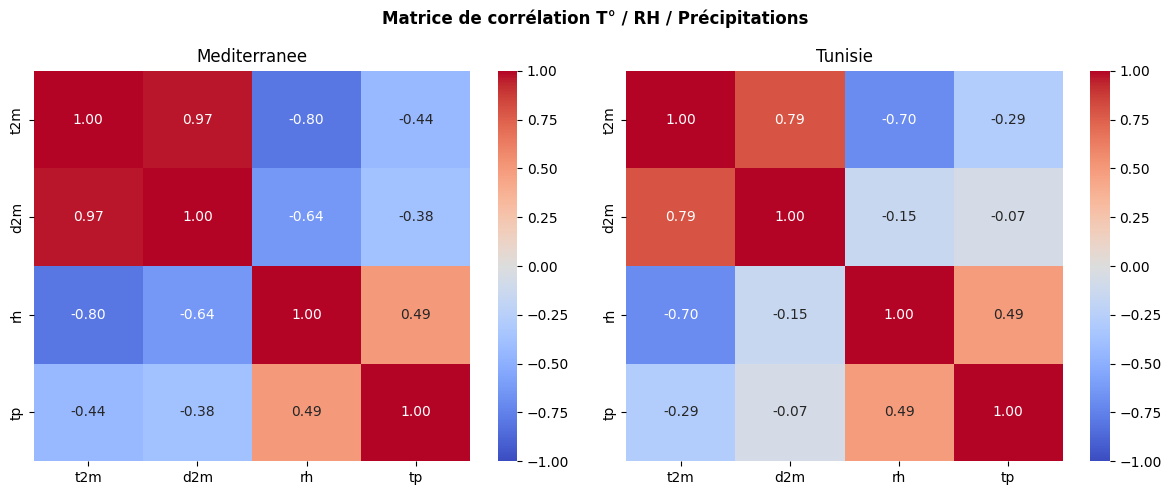

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, zone in zip(axes, ['mediterranee', 'tunisie']):
    corr = df[df.zone == zone][['t2m', 'd2m', 'rh', 'tp']].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, vmin=-1, vmax=1)
    ax.set_title(zone.title())
fig.suptitle('Matrice de corrélation T° / RH / Précipitations', fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Stress hydrique — Précipitations cumulées par saison

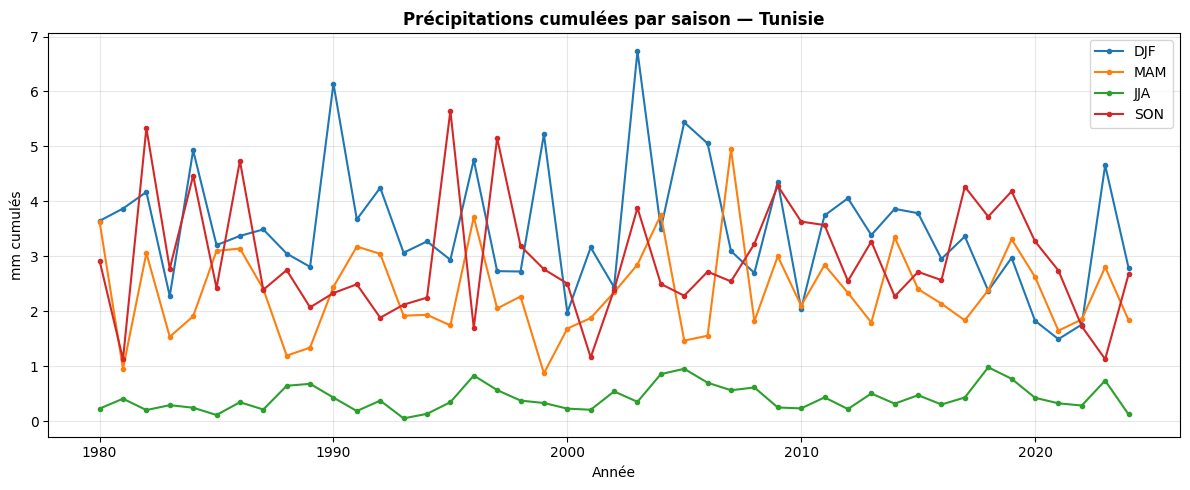

In [6]:
# Cumul saisonnier des précipitations (mm)
rain = (df.groupby(['year', 'season', 'zone'])['tp']
        .sum()
        .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
for season in ['DJF', 'MAM', 'JJA', 'SON']:
    sub = rain[(rain.zone == 'tunisie') & (rain.season == season)]
    ax.plot(sub.year, sub.tp, label=season, marker='o', markersize=3)
ax.set_title('Précipitations cumulées par saison — Tunisie', fontweight='bold')
ax.set_xlabel('Année'); ax.set_ylabel('mm cumulés')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Synthèse — Indicateurs clés

À remplir après exécution sur les données complètes :
- Pente de la tendance T° (°C/décennie) en Tunisie vs Méditerranée
- Évolution du nombre de jours de canicule (avant/après 2000)
- Corrélation T° / RH (anti-corrélation attendue)
- Évolution des précipitations annuelles